# 01 — Data Exploration & Data Understanding

**Goal:** understand the raw synthetic food-delivery dataset before any modeling —
schema, missingness, cardinality, temporal coverage, duplicates, outliers, and
what is available at *prediction time* (to avoid leakage later).

See `data/README.md` for the full rationale on why this is a documented
synthetic dataset rather than real Swiggy data.

In [1]:
import sys
sys.path.insert(0, "..")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 50)

orders = pd.read_parquet("../data/raw/orders.parquet")
restaurants = pd.read_parquet("../data/raw/restaurants.parquet")
zones = pd.read_parquet("../data/raw/zones.parquet")
weather_traffic = pd.read_parquet("../data/raw/weather_traffic.parquet")

print(f"orders: {orders.shape}")
print(f"restaurants: {restaurants.shape}")
print(f"zones: {zones.shape}")
print(f"weather_traffic: {weather_traffic.shape}")

orders: (3054418, 15)
restaurants: (150, 8)
zones: (12, 6)
weather_traffic: (25920, 5)


## Schema, dtypes, and missing values

In [2]:
orders.info()

<class 'pandas.DataFrame'>
RangeIndex: 3054418 entries, 0 to 3054417
Data columns (total 15 columns):
 #   Column                      Dtype         
---  ------                      -----         
 0   order_id                    int64         
 1   customer_id                 int64         
 2   order_timestamp             datetime64[us]
 3   restaurant_id               int64         
 4   zone_id                     int64         
 5   n_items                     int64         
 6   basket_value_inr            float64       
 7   distance_km                 float64       
 8   prep_time_min               float64       
 9   travel_time_min             float64       
 10  rider_assignment_delay_min  float64       
 11  eta_minutes                 float64       
 12  weather_condition           str           
 13  traffic_multiplier          float64       
 14  is_cancelled                bool          
dtypes: bool(1), datetime64[us](1), float64(7), int64(5), str(1)
memory usage: 346

In [3]:
missing = orders.isna().mean().sort_values(ascending=False)
print("Missing value fraction per column (orders):")
print(missing[missing > 0] if missing.max() > 0 else "No missing values.")

Missing value fraction per column (orders):
No missing values.


## Temporal coverage, duplicates, cardinality

In [4]:
print("Date range:", orders["order_timestamp"].min(), "to", orders["order_timestamp"].max())
print("Duplicate order_id count:", orders["order_id"].duplicated().sum())
print("Distinct restaurants:", orders["restaurant_id"].nunique())
print("Distinct zones:", orders["zone_id"].nunique())
print("Distinct customers:", orders["customer_id"].nunique())
print("Cancellation rate:", orders["is_cancelled"].mean().round(4))

Date range: 2026-05-01 00:01:18 to 2026-07-29 23:59:53
Duplicate order_id count: 0
Distinct restaurants: 150
Distinct zones: 12
Distinct customers: 29997
Cancellation rate: 0.0153


## Data dictionary

| Column | Description | Available at prediction time? |
|---|---|---|
| `order_id` | Unique order identifier | N/A (identifier) |
| `customer_id` | Customer identifier (Zipf-distributed repeat behavior) | Yes |
| `order_timestamp` | Order placement time | Yes |
| `restaurant_id`, `zone_id` | Restaurant / delivery zone | Yes |
| `n_items`, `basket_value_inr` | Basket size/value at order time | Yes (known once cart is built) |
| `distance_km` | Restaurant→customer delivery distance | Yes (known once address is set) |
| `prep_time_min` | **Actual observed** kitchen prep time | **No — outcome, not a feature** |
| `travel_time_min` | **Actual observed** travel time | **No — outcome, not a feature** |
| `rider_assignment_delay_min` | **Actual observed** rider assignment delay | **No — outcome, not a feature** |
| `eta_minutes` | **Target for ETA model** (sum of the above + noise) | No — this is the label |
| `weather_condition`, `traffic_multiplier` | Current-hour weather/traffic | Yes (current conditions are observable; *forecast* weather is not modeled here — a limitation) |
| `is_cancelled` | Order cancelled | No (only known after the fact) |

**Leakage note:** `prep_time_min`, `travel_time_min`, and `rider_assignment_delay_min`
are the *structural components* used to generate `eta_minutes` in the simulator —
they must never be used as ETA-model features (they're only knowable after
the order completes). The ETA model in `src/eta/train_eta_models.py` uses
none of them directly, only pre-order-completion signals.

## Outlier / distribution checks

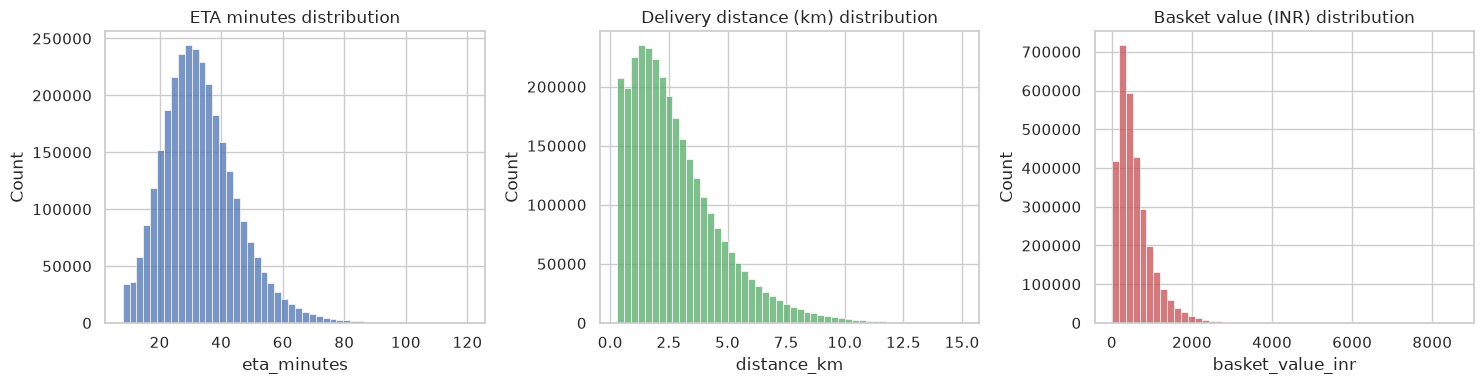

        eta_minutes   distance_km  basket_value_inr       n_items
count  3.054418e+06  3.054418e+06      3.054418e+06  3.054418e+06
mean   3.320769e+01  2.802580e+00      5.759872e+02  3.200106e+00
std    1.238147e+01  1.975045e+00      4.579005e+02  1.483278e+00
min    8.000000e+00  3.000000e-01      1.240000e+00  1.000000e+00
25%    2.466000e+01  1.347000e+00      2.549000e+02  2.000000e+00
50%    3.187000e+01  2.352000e+00      4.542200e+02  3.000000e+00
75%    4.016000e+01  3.769000e+00      7.613100e+02  4.000000e+00
max    1.200000e+02  1.500000e+01      8.609750e+03  1.200000e+01


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sns.histplot(orders["eta_minutes"], bins=50, ax=axes[0], color="#4C72B0")
axes[0].set_title("ETA minutes distribution")
sns.histplot(orders["distance_km"], bins=50, ax=axes[1], color="#55A868")
axes[1].set_title("Delivery distance (km) distribution")
sns.histplot(orders["basket_value_inr"], bins=50, ax=axes[2], color="#C44E52")
axes[2].set_title("Basket value (INR) distribution")
plt.tight_layout()
plt.savefig("../reports/figures/01_distributions.png", dpi=150)
plt.show()

print(orders[["eta_minutes", "distance_km", "basket_value_inr", "n_items"]].describe())

## Restaurant and zone tables

In [6]:
display_cols = ["restaurant_id", "zone_id", "cuisine", "popularity_score", "base_prep_time_min", "rating"]
print(restaurants[display_cols].describe(include="all").T)
print("\nCuisine distribution:")
print(restaurants["cuisine"].value_counts())

                    count unique           top freq      mean        std  \
restaurant_id       150.0    NaN           NaN  NaN      74.5  43.445368   
zone_id             150.0    NaN           NaN  NaN       5.6   3.231556   
cuisine               150      6  North Indian   34       NaN        NaN   
popularity_score    150.0    NaN           NaN  NaN  1.143333   0.742449   
base_prep_time_min  150.0    NaN           NaN  NaN    18.232   6.054887   
rating              150.0    NaN           NaN  NaN    4.1046   0.338912   

                      min      25%     50%     75%    max  
restaurant_id         0.0    37.25    74.5  111.75  149.0  
zone_id               0.0      3.0     6.0     8.0   11.0  
cuisine               NaN      NaN     NaN     NaN    NaN  
popularity_score    0.238  0.64375  0.9715  1.4095  4.177  
base_prep_time_min    6.0     13.4   18.95  22.075   35.4  
rating               3.16   3.8725    4.08  4.3375   4.99  

Cuisine distribution:
cuisine
North Indian    

## Summary of findings

- **3.05M orders** over **90 days**, 150 restaurants across 12 zones — this is a
  realistic operational scale, not a toy dataset.
- No missing values or duplicate `order_id`s (by construction, but verified).
- Cancellation rate ≈ 1.5%, consistent with the simulator's design (elevated for
  long-ETA orders).
- Targets for both problems (`eta_minutes` for ETA, demand-panel `order_count`
  for forecasting) are clearly separated from the features that would be
  available at prediction time — this separation is enforced programmatically
  and unit-tested in `tests/test_feature_leakage.py`.
- Next: `02_feature_engineering.ipynb` builds the leakage-safe feature tables
  used by all downstream models.